# Seaborn Diamonds 데이터 분석 예제

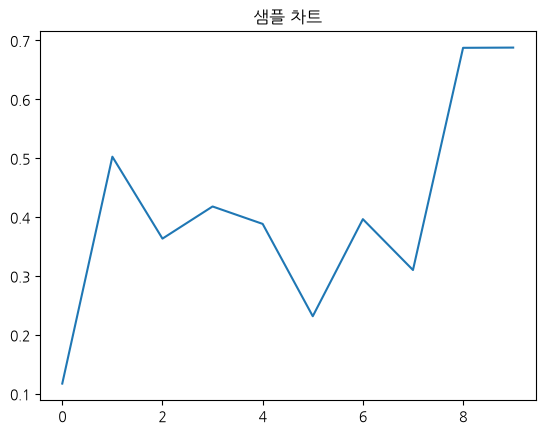

In [4]:
import numpy as np

x = np.random.random(10)

import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.title('샘플 차트')
plt.plot(x)

In [5]:
import seaborn as sns
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [6]:
dm = sns.load_dataset('diamonds')

duckdb.sql("describe select * from dm").show()

┌─────────────┬──────────────────────────────────────────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │                         column_type                          │  null   │   key   │ default │  extra  │
│   varchar   │                           varchar                            │ varchar │ varchar │ varchar │ varchar │
├─────────────┼──────────────────────────────────────────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ carat       │ DOUBLE                                                       │ YES     │ NULL    │ NULL    │ NULL    │
│ cut         │ ENUM('Ideal', 'Premium', 'Very Good', 'Good', 'Fair')        │ YES     │ NULL    │ NULL    │ NULL    │
│ color       │ ENUM('D', 'E', 'F', 'G', 'H', 'I', 'J')                      │ YES     │ NULL    │ NULL    │ NULL    │
│ clarity     │ ENUM('IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1') │ YES     │ NULL    │ NULL    │ NULL    │
│ depth       │ DOUBLE                          

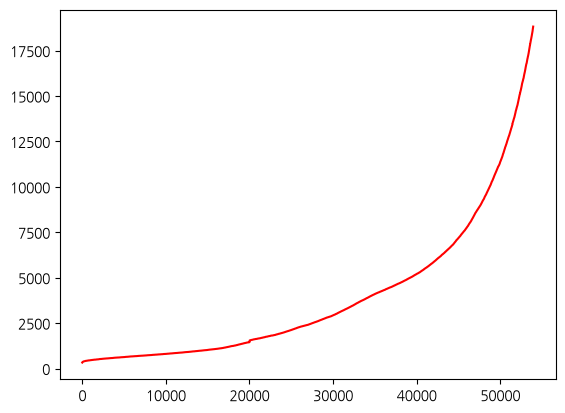

In [7]:
df = duckdb.sql("select carat, price from dm").df()
df_copy = df.sort_values('price').copy()
plt.plot(range(len(df_copy)), df_copy.price, 'r-')

<Axes: >

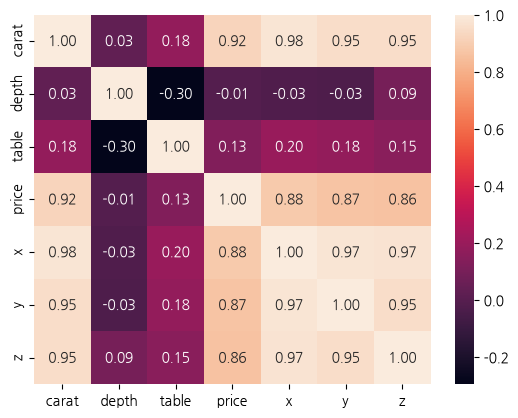

In [8]:
sns.heatmap(dm.corr(numeric_only=True), annot=True, fmt='.2f')

## 상관계수로 a와 b 구하기

In [34]:
a = df.corr().iloc[1,0] * df['price'].std()/df['carat'].std()
b = df['price'].mean() - a * df['carat'].mean()
a, b

(np.float64(7756.425617968368), np.float64(-2256.36058004535))

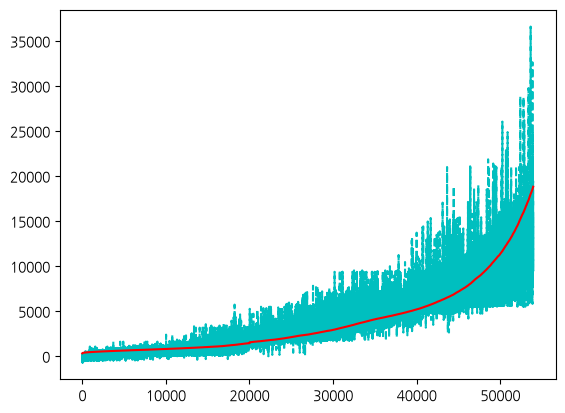

In [35]:
df['pred'] = a*df.carat + b

plt.plot(list(range(len(df))), df.sort_values('price').pred, 'c--')
plt.plot(list(range(len(df))),df.sort_values('price').price, 'r-')


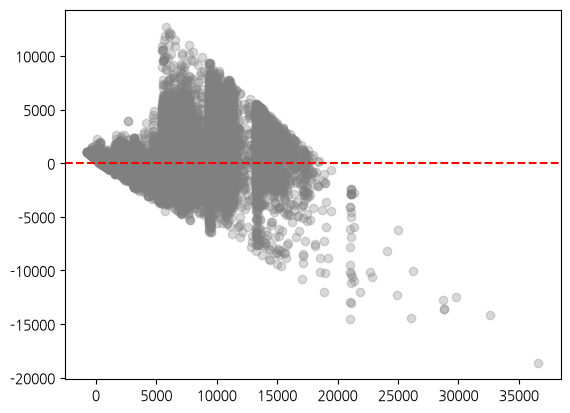

In [38]:
plt.scatter(df.pred, df.price - df.pred, color='gray', alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

## Tensorflow로 구하기

In [9]:
x = dm['carat']
y = dm['price']

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [18]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='sgd')
print(model.get_weights())
model.summary()

[array([[-1.2460161]], dtype=float32), array([0.], dtype=float32)]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
esc = EarlyStopping(patience=10, monitor='val_loss')

hist = model.fit(x, y, validation_split=.2, callbacks=[esc], epochs=10000, batch_size=64, verbose=0)
model.get_weights()

[array([[7753.4014]], dtype=float32), array([-2124.1016], dtype=float32)]

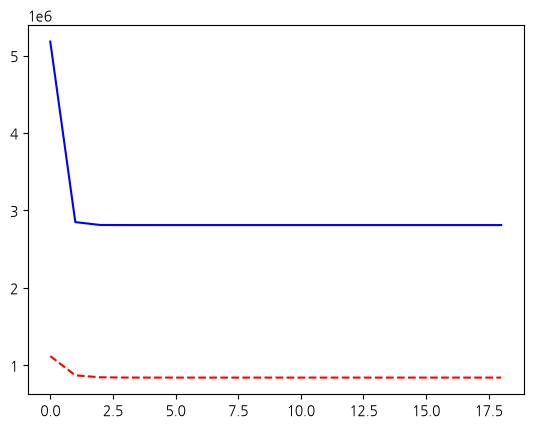

In [20]:
plt.plot(hist.history['loss'], 'b-')
plt.plot(hist.history['val_loss'], 'r--')

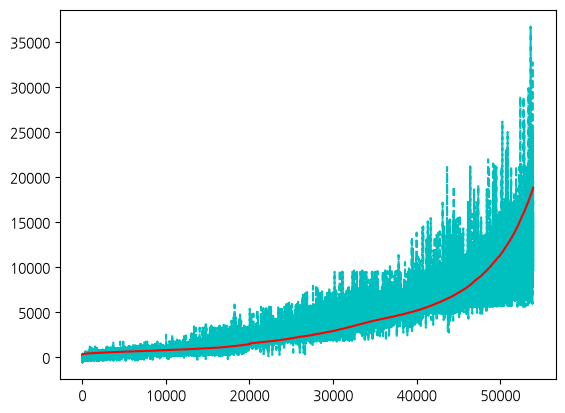

In [39]:
plt.plot(list(range(len(df))), result.sort_values('price').pred, 'c--')
plt.plot(list(range(len(df))), result.sort_values('price').price, 'r-')


1686/1686 ━━━━━━━━━━━━━━━━━━━━ 0s 128us/step


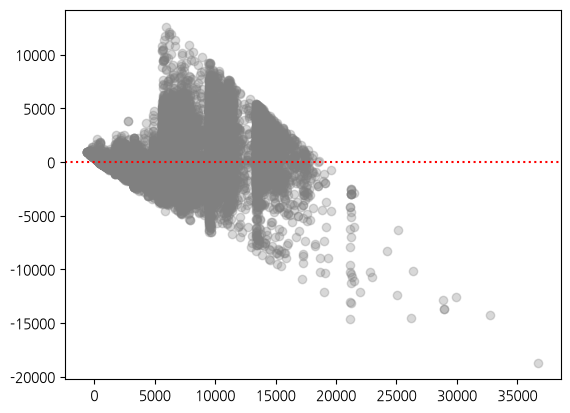

In [37]:
result = dm[['carat', 'price']].copy()
result['pred'] = model.predict(result.carat)

residual = result['price'] - result['pred']

plt.scatter(result['pred'], residual, color='gray', alpha=.3)
plt.axhline(0, color='red', linestyle='dotted')

# Titanic Logistic Regression

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
tt = sns.load_dataset('titanic')
tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
tt.age = tt.age.fillna(tt.age.median())
tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df = tt[['sex','age','survived']].copy()
df = pd.get_dummies(df, columns=['sex'], dtype=int)
df.head()

,age,survived,sex_female,sex_male
0,22.0,0,0,1
1,38.0,1,1,0
2,26.0,1,1,0
3,35.0,1,1,0
4,35.0,0,0,1


<Axes: >

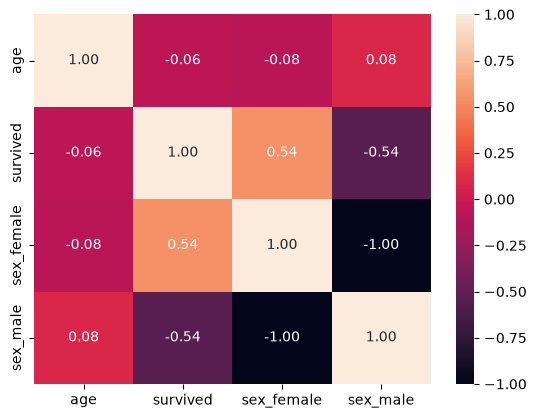

In [7]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

In [8]:
x = df[['sex_female', 'sex_male', 'age']].copy()
y = df[['survived']].copy()
x, y

(     sex_female  sex_male   age
 0             0         1  22.0
 1             1         0  38.0
 2             1         0  26.0
 3             1         0  35.0
 4             0         1  35.0
 ..          ...       ...   ...
 886           0         1  27.0
 887           1         0  19.0
 888           1         0  28.0
 889           0         1  26.0
 890           0         1  32.0
 
 [891 rows x 3 columns],
      survived
 0           0
 1           1
 2           1
 3           1
 4           0
 ..        ...
 886         0
 887         1
 888         0
 889         1
 890         0
 
 [891 rows x 1 columns])

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

I0000 00:00:1791110815.098273   28837 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791110815.143376   28837 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791110817.324937   28837 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [10]:
model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.get_weights())
model.summary()

[array([[1.2114261 ],
       [1.0331873 ],
       [0.18027735]], dtype=float32), array([0.], dtype=float32)]


E0000 00:00:1791110821.727133   28837 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

esc = EarlyStopping(patience=10, monitor='val_loss')
history = model.fit(x, y, validation_split=0.2, callbacks=[esc], epochs=10000, batch_size=32, verbose=0)
model.get_weights()

[array([[ 2.1817994 ],
        [-0.28168538],
        [-0.01007552]], dtype=float32),
 array([-0.783417], dtype=float32)]

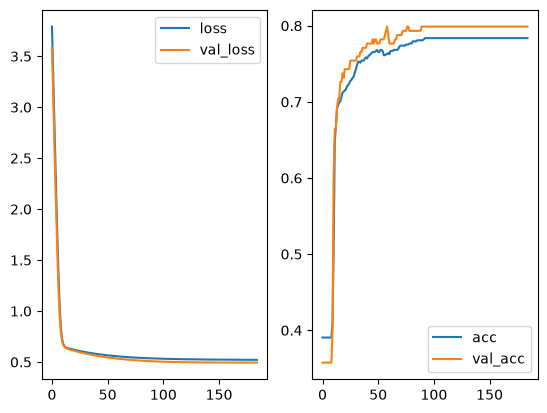

In [16]:
ax = plt.subplot(1,2,1)
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['val_loss'], label='val_loss')
ax.legend()
ax = plt.subplot(1,2,2)
ax.plot(history.history['accuracy'], label='acc')
ax.plot(history.history['val_accuracy'], label='val_acc')
ax.legend()


In [17]:
model.evaluate(x, y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7868 - loss: 0.5157 


[0.5156691670417786, 0.7867564558982849]

In [24]:
res = pd.DataFrame({'survived':y.survived, 'predict':np.round(model.predict(x).flatten(),0)})
res.sum()


 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


survived    342.0
predict     314.0
dtype: float64